# Optimization

Optimization is the engine under the hood of quantitative finance. **Fitting a
model** is minimising a loss (or maximising a likelihood); **building a
portfolio** is minimising risk subject to constraints; **calibrating** a pricing
model is matching market quotes. Master a few ideas and these all look the same.

* **Unconstrained minimisation** — follow the gradient downhill to a minimum.
* **Convexity** — a convex problem has a *single* global minimum, so local
  search is guaranteed to find it. Most well-posed finance problems are convex
  (min-variance) or made convex by reparameterisation.
* **Constrained optimization** — **Lagrange multipliers** turn equality
  constraints into an unconstrained problem; **SLSQP** handles equalities *and*
  inequalities (the basis of `qufin.portfolio`).

**Roadmap**

1. Unconstrained minimisation & gradient descent
2. Root finding (Newton's method)
3. Constrained optimization — Lagrange multipliers & SLSQP
4. Worked example: the **mean-variance portfolio**
5. **Maximum likelihood** = optimization (the link to model fitting)


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize, stats

from qufin.portfolio import min_variance, max_sharpe, efficient_frontier

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 1. Unconstrained minimisation & gradient descent

**Gradient descent** steps in the direction of steepest decrease,
$x \leftarrow x - \eta\,\nabla f(x)$. On a convex bowl it marches straight to
the unique minimum. We minimise a simple convex quadratic and overlay the
descent path; `scipy.optimize.minimize` does the same with smarter step sizes.


gradient descent  -> (1.000, -2.000)
scipy BFGS        -> (1.000, -2.000)  in 8 iters  (true: 1, -2)


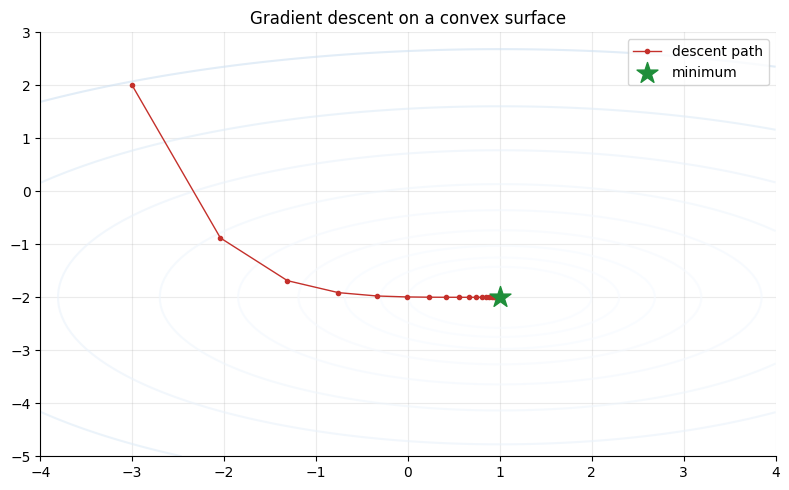

In [2]:
def f(p):                      # convex bowl, minimum at (1, -2)
    x, y = p
    return (x - 1)**2 + 3 * (y + 2)**2

def grad(p):
    x, y = p
    return np.array([2 * (x - 1), 6 * (y + 2)])

# Hand-rolled gradient descent.
path = [np.array([-3.0, 2.0])]
eta = 0.12
for _ in range(40):
    path.append(path[-1] - eta * grad(path[-1]))
path = np.array(path)

res = optimize.minimize(f, x0=[-3.0, 2.0], method='BFGS')
print(f'gradient descent  -> ({path[-1,0]:.3f}, {path[-1,1]:.3f})')
print(f'scipy BFGS        -> ({res.x[0]:.3f}, {res.x[1]:.3f})  in {res.nit} iters  (true: 1, -2)')

gx, gy = np.meshgrid(np.linspace(-4, 4, 80), np.linspace(-5, 3, 80))
gz = (gx - 1)**2 + 3 * (gy + 2)**2
fig, ax = plt.subplots(figsize=(8, 5))
ax.contour(gx, gy, gz, levels=np.logspace(0, 2.5, 12), cmap='Blues', alpha=0.6)
ax.plot(path[:, 0], path[:, 1], 'o-', color='#c4302b', ms=3, lw=1, label='descent path')
ax.scatter([1], [-2], color='#1f8e3a', marker='*', s=250, zorder=4, label='minimum')
ax.set_title('Gradient descent on a convex surface'); ax.legend()
plt.tight_layout(); plt.show()


## 2. Root finding — Newton's method

Many problems reduce to solving $g(x)=0$: the internal rate of return, a
break-even level, or **implied volatility** (notebook 09). **Newton's method**
iterates $x \leftarrow x - g(x)/g'(x)$ and converges quadratically near the root.
Here we invert a monotinic function to recover a target.


In [3]:
# Solve g(x) = x^3 + 2x - 5 = 0.
g = lambda x: x**3 + 2 * x - 5
gp = lambda x: 3 * x**2 + 2
x = 1.0
hist = [x]
for _ in range(8):
    x = x - g(x) / gp(x)
    hist.append(x)
root_bisect = optimize.brentq(g, 0, 3)        # robust bracketing method
print('Newton iterates:', [f'{h:.6f}' for h in hist[:6]])
print(f'Newton root  = {hist[-1]:.10f}')
print(f'brentq root  = {root_bisect:.10f}  (agree)')
print(f'check g(root) = {g(hist[-1]):.2e}')


Newton iterates: ['1.000000', '1.400000', '1.330964', '1.328273', '1.328269', '1.328269']
Newton root  = 1.3282688557
brentq root  = 1.3282688557  (agree)
check g(root) = 0.00e+00


## 3. Constrained optimization — Lagrange multipliers & SLSQP

Real problems carry constraints: portfolio weights must **sum to one**, positions
must be **non-negative**, exposure is **capped**. For an *equality* constraint
the **method of Lagrange multipliers** says the gradient of the objective must be
parallel to the gradient of the constraint at the optimum.

Minimise $f=x^2+y^2$ subject to $x+y=1$: the analytic answer is
$(\tfrac12,\tfrac12)$. `scipy.optimize.minimize(method='SLSQP')` handles this —
and, unlike pure Lagrange multipliers, also inequality constraints — which is
exactly how the portfolio optimizers are built.


constrained minimum = (0.500, 0.500)   (analytic: 0.5, 0.5)
with x >= 0.7       = (0.700, 0.300)   (constraint binds at x=0.7)


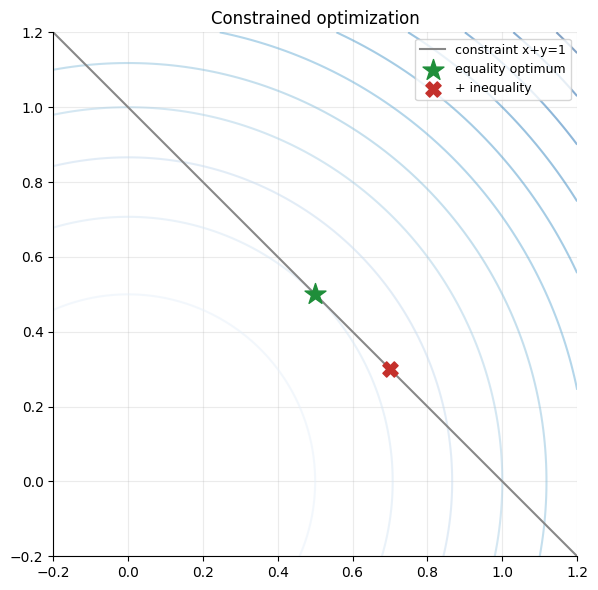

In [4]:
obj = lambda p: p[0]**2 + p[1]**2
cons = [{'type': 'eq', 'fun': lambda p: p[0] + p[1] - 1.0}]
sol = optimize.minimize(obj, x0=[0.0, 1.0], method='SLSQP', constraints=cons)
print(f'constrained minimum = ({sol.x[0]:.3f}, {sol.x[1]:.3f})   (analytic: 0.5, 0.5)')

# Add an inequality: also require x >= 0.7  ->  optimum slides along the line.
cons2 = cons + [{'type': 'ineq', 'fun': lambda p: p[0] - 0.7}]
sol2 = optimize.minimize(obj, x0=[0.8, 0.2], method='SLSQP', constraints=cons2)
print(f'with x >= 0.7       = ({sol2.x[0]:.3f}, {sol2.x[1]:.3f})   '
      '(constraint binds at x=0.7)')

xs = np.linspace(-0.2, 1.2, 50)
fig, ax = plt.subplots(figsize=(6.5, 6))
gx, gy = np.meshgrid(np.linspace(-0.2, 1.2, 80), np.linspace(-0.2, 1.2, 80))
ax.contour(gx, gy, gx**2 + gy**2, levels=12, cmap='Blues', alpha=0.5)
ax.plot(xs, 1 - xs, color='#888', lw=1.5, label='constraint x+y=1')
ax.scatter(*sol.x, color='#1f8e3a', marker='*', s=250, zorder=4, label='equality optimum')
ax.scatter(*sol2.x, color='#c4302b', marker='X', s=120, zorder=4, label='+ inequality')
ax.set_title('Constrained optimization'); ax.legend(fontsize=9); ax.set_aspect('equal')
plt.tight_layout(); plt.show()


## 4. Worked example — the mean-variance portfolio

Markowitz's problem is a constrained optimization:
$\min_w w^\top\Sigma w$ subject to $\sum w = 1$ (and $w\ge 0$ if long-only).
`qufin.portfolio` wraps SLSQP into ready-made solvers. We build a small universe,
trace the **efficient frontier**, and mark the minimum-variance and maximum-Sharpe
points — the full treatment is notebook 24.


min-variance weights: {'equity': 0.1, 'bond': 0.7, 'gold': 0.03, 'credit': 0.17}
max-Sharpe   weights: {'equity': 0.25, 'bond': 0.48, 'gold': 0.07, 'credit': 0.19}


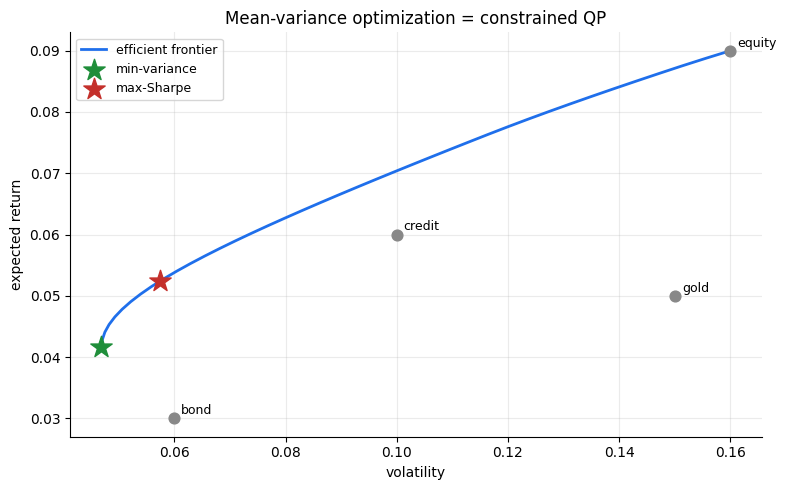

In [5]:
names = ['equity', 'bond', 'gold', 'credit']
mu = np.array([0.09, 0.03, 0.05, 0.06])           # annualised expected returns
vols = np.array([0.16, 0.06, 0.15, 0.10])
corr = np.array([[1.0, -0.3, 0.1, 0.6],
                 [-0.3, 1.0, 0.2, -0.1],
                 [0.1, 0.2, 1.0, 0.0],
                 [0.6, -0.1, 0.0, 1.0]])
cov = corr * np.outer(vols, vols)

mv = min_variance(mu, cov, names)
ms = max_sharpe(mu, cov, names, risk_free_rate=0.02)
ef = efficient_frontier(mu, cov, names, n_points=40)
print('min-variance weights:', {k: round(v, 2) for k, v in mv.as_dict().items()})
print('max-Sharpe   weights:', {k: round(v, 2) for k, v in ms.as_dict().items()})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ef.volatilities, ef.returns, '-', color='#1f6feb', lw=2, label='efficient frontier')
ax.scatter(vols, mu, color='#888', s=60, zorder=3)
for i, n_ in enumerate(names):
    ax.annotate(n_, (vols[i], mu[i]), xytext=(5, 3), textcoords='offset points', fontsize=9)
ax.scatter(mv.expected_volatility, mv.expected_return, color='#1f8e3a', marker='*', s=260,
           zorder=4, label='min-variance')
ax.scatter(ms.expected_volatility, ms.expected_return, color='#c4302b', marker='*', s=260,
           zorder=4, label='max-Sharpe')
ax.set_xlabel('volatility'); ax.set_ylabel('expected return')
ax.set_title('Mean-variance optimization = constrained QP'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 5. Maximum likelihood = optimization

Fitting a statistical model **is** an optimization: choose the parameters that
make the observed data most likely, i.e. maximise the log-likelihood (equivalently
minimise its negative). Every model in this collection — ARIMA, GARCH,
Markov-switching — is fit this way under the hood. Here we recover the parameters
of a normal distribution by numerical MLE and confirm they match the
closed-form sample estimates.


MLE      : mu=1.444  sigma=2.000
sample   : mu=1.444  sigma=2.000  (MLE matches closed form)
true     : mu=1.500  sigma=2.000


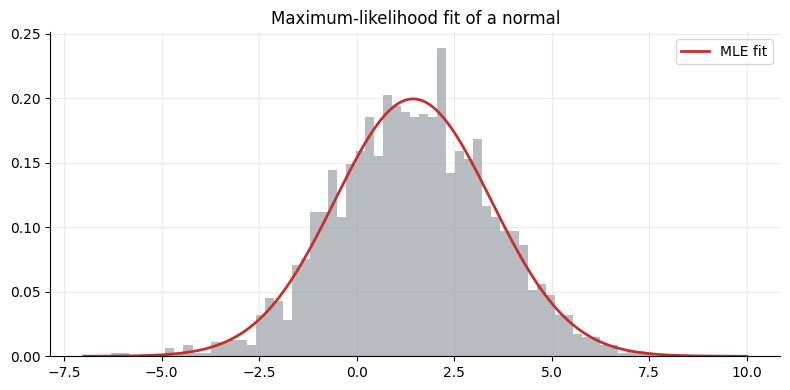

In [6]:
rng = np.random.default_rng(0)
data = rng.normal(loc=1.5, scale=2.0, size=2000)     # true mu=1.5, sigma=2.0

def neg_log_lik(params):
    mu_p, log_sigma = params                          # optimise log-sigma to keep sigma > 0
    sigma_p = np.exp(log_sigma)
    return -np.sum(stats.norm.logpdf(data, mu_p, sigma_p))

opt = optimize.minimize(neg_log_lik, x0=[0.0, 0.0], method='BFGS')
mu_hat, sigma_hat = opt.x[0], np.exp(opt.x[1])
print(f'MLE      : mu={mu_hat:.3f}  sigma={sigma_hat:.3f}')
print(f'sample   : mu={data.mean():.3f}  sigma={data.std():.3f}  (MLE matches closed form)')
print(f'true     : mu=1.500  sigma=2.000')

grid = np.linspace(-7, 10, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data, bins=60, density=True, color='#9aa0a6', alpha=0.7)
ax.plot(grid, stats.norm.pdf(grid, mu_hat, sigma_hat), color='#c4302b', lw=2, label='MLE fit')
ax.set_title('Maximum-likelihood fit of a normal'); ax.legend()
plt.tight_layout(); plt.show()


## What next?

* **Portfolio optimization (notebook 24)** is the full mean-variance treatment —
  shrinkage, risk parity, the capital market line, and out-of-sample fragility.
* **GARCH (notebook 15)** and **ARIMA (notebook 14)** are MLE problems solved
  exactly like §5, just with a likelihood that depends on the whole series.
* **Monte Carlo & numerical methods (notebook 09)** revisits root-finding to
  back out implied volatility from option prices.
